In [8]:
# Import necessary libraries
import pandas as pd
import nltk
import re
import string
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()  
    text = re.sub(r'https?://\S+|www\.\S+', '', text) 
    text = re.sub(r'\[.*?\]', '', text) 
    text = re.sub(r'\W+', ' ', text) 
    text = re.sub(r'\d+', '', text)  
    text = text.translate(str.maketrans('', '', string.punctuation)) 
    text = " ".join([word for word in text.split() if word not in stop_words])  
    return text


fake_news = pd.read_csv('fake_cleaned.csv')
real_news = pd.read_csv('true_cleaned.csv')

fake_news['label'] = 0  
real_news['label'] = 1  
data = pd.concat([fake_news, real_news], ignore_index=True)

data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data['text'] = data['text'].apply(preprocess_text)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [10]:
X = data['text']
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=10000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

svm_model = SVC(probability=True, random_state=42) 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
rf_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
y_pred_rf = rf_model.predict(X_test_tfidf)

In [ ]:
print("Support Vector Machine Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-Score:", f1_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

print("\nRandom Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

print("\nComparison:")
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Support Vector Machine Performance:
Accuracy: 0.9943259192010894
Precision: 0.9922096317280453
Recall: 0.9959715639810427
F1-Score: 0.9940870387890256
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4592
           1       0.99      1.00      0.99      4220

    accuracy                           0.99      8812
   macro avg       0.99      0.99      0.99      8812
weighted avg       0.99      0.99      0.99      8812


Random Forest Performance:
Accuracy: 0.9985247389922832
Precision: 0.9976342559735036
Recall: 0.9992890995260664
F1-Score: 0.99846099206819
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4592
           1       1.00      1.00      1.00      4220

    accuracy                           1.00      8812
   macro avg       1.00      1.00      1.00      8812
weighted avg       1.00      1.00      1.00      8812


Comparison:
SVM Accuracy: 0.9943
Random Forest Accura

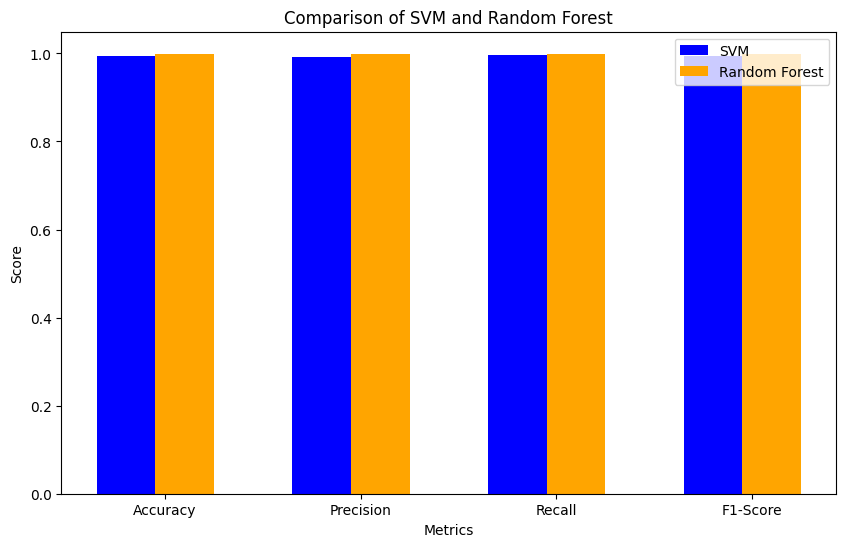

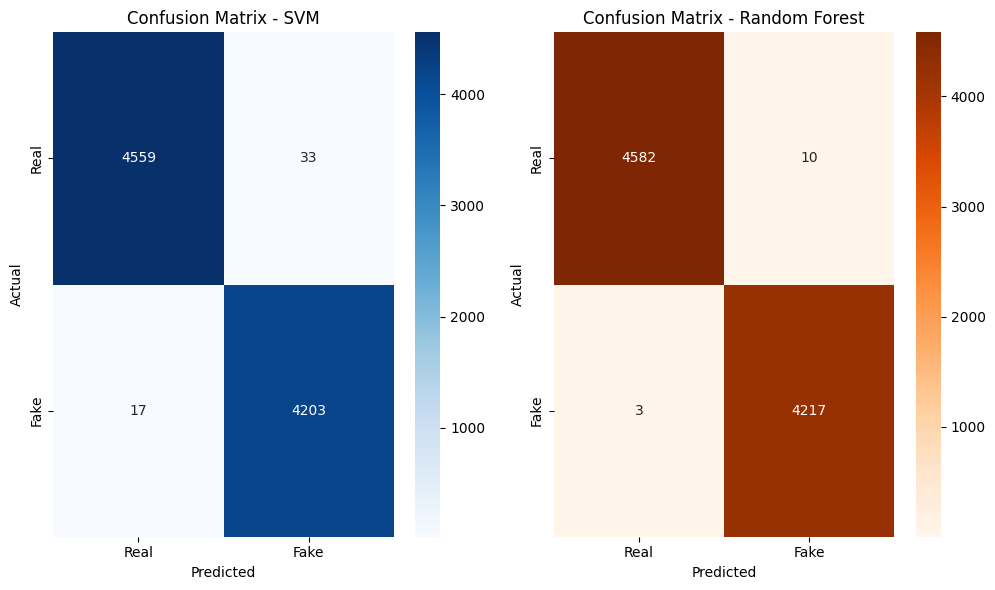

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
svm_scores = [
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm)
]
rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = range(len(metrics))
plt.figure(figsize=(10, 6))
plt.bar(x, svm_scores, width=0.3, label='SVM', color='blue')
plt.bar([i + 0.3 for i in x], rf_scores, width=0.3, label='Random Forest', color='orange')
plt.xticks([i + 0.2 for i in x], metrics)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Comparison of SVM and Random Forest')
plt.legend()
plt.show()

plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
cm_lr = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 3, 2)
cm_nb = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


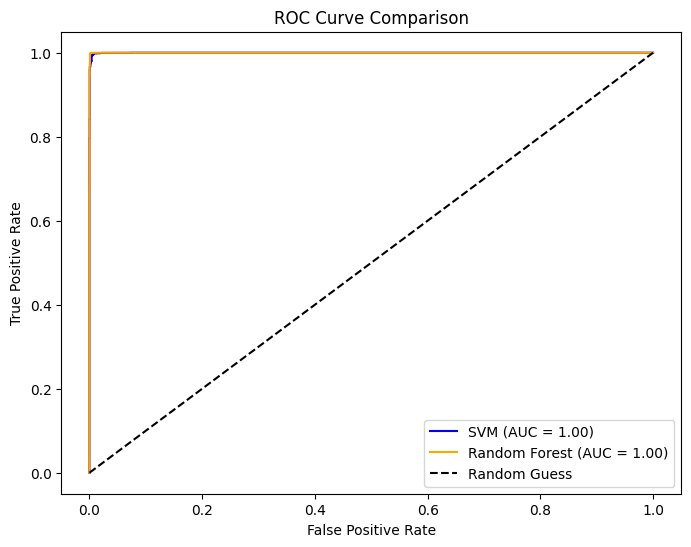

In [7]:
plt.figure(figsize=(8, 6))

y_pred_prob_svm = svm_model.predict_proba(X_test_tfidf)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.2f})', color='blue')

y_pred_prob_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', color='orange')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [6]:
import shap
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2

# 1. Feature Selection (to make SHAP computation faster)
selector = SelectKBest(chi2, k=1000)  # Select top 1000 features
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())[selector.get_support()]

# 2. Retrain models on selected features
svm_model.fit(X_train_selected, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# SHAP for SVM (using KernelExplainer)
print("Computing SHAP values for SVM...")
explainer_svm = shap.KernelExplainer(
    svm_model.predict_proba,
    shap.sample(X_train_selected.toarray(), 100),
    link="logit"
)

shap_values_svm = explainer_svm.shap_values(
    X_test_selected[:100].toarray(),  
    nsamples=100,
    l1_reg="num_features(20)"
)

SHAP values shape: (100, 1000)
Feature matrix shape: (100, 1000)


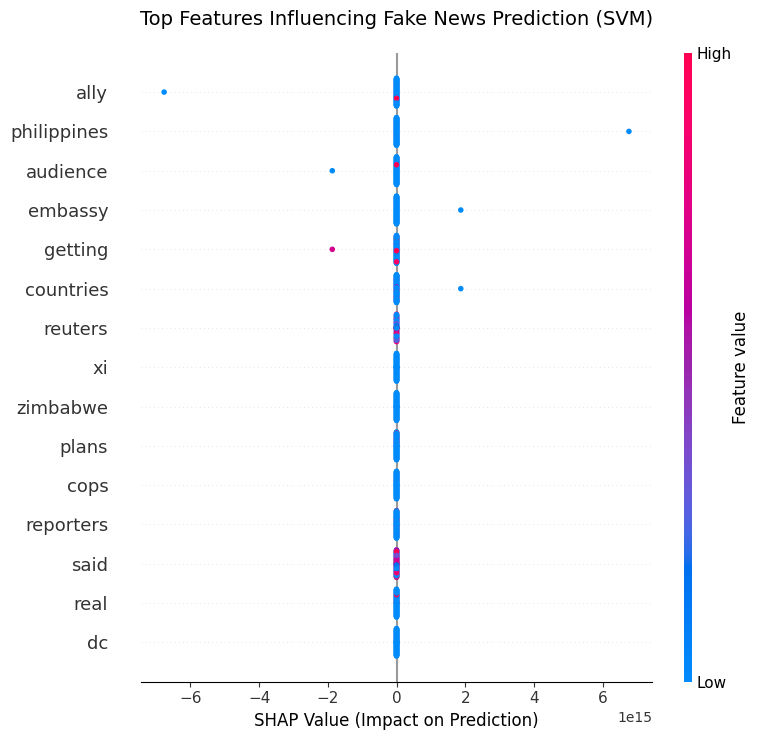

In [ ]:
shap_values_class1_svm = shap_values_svm[:,:,1]  # Shape (100, 1000)

# Prepare the feature matrix
X_test_dense = X_test_selected[:100].toarray()

# Verify alignment
print(f"SHAP values shape: {shap_values_class1_svm.shape}")
print(f"Feature matrix shape: {X_test_dense.shape}")

# Create the plot with proper settings
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_class1_svm,
    X_test_dense,
    feature_names=feature_names,
    plot_type="dot",
    max_display=15,
    show=False
)
plt.title("Top Features Influencing Fake News Prediction (SVM)", fontsize=14, pad=20)
plt.xlabel("SHAP Value (Impact on Prediction)", fontsize=12)
plt.tight_layout()
plt.show()

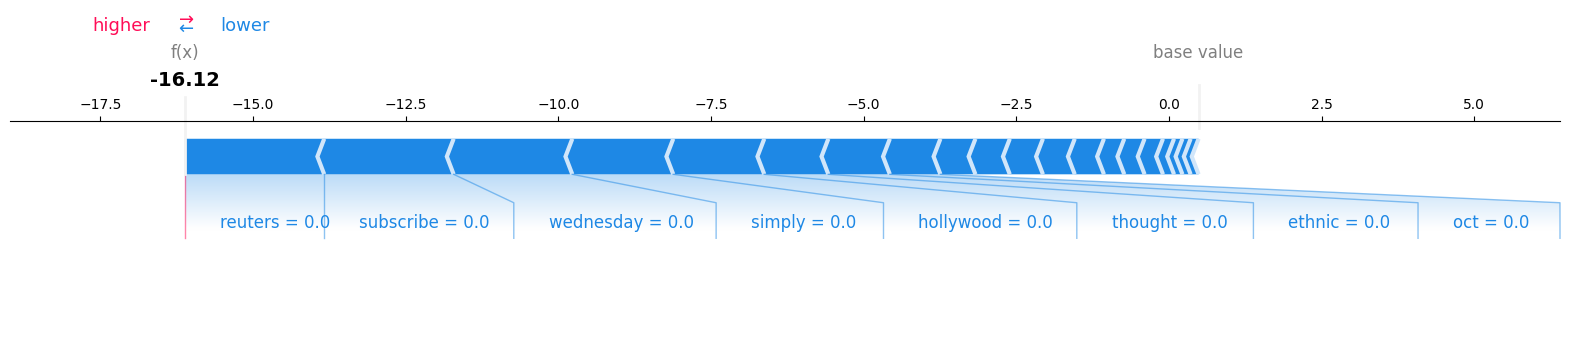

<Figure size 640x480 with 0 Axes>

In [ ]:
shap.plots.force(
    base_value=explainer_svm.expected_value[1],
    shap_values=shap_values_svm[0, :, 1],
    features=X_test_selected[0].toarray().flatten(),
    feature_names=feature_names,
    matplotlib=True 
)
plt.tight_layout()
plt.show()

In [ ]:
X_train_selected_rf = selector.fit_transform(X_train_tfidf, y_train).astype(np.float32)
X_test_selected_rf = selector.transform(X_test_tfidf).astype(np.float32)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())[selector.get_support()]

# Retrain model on selected features
rf_model.fit(X_train_selected_rf, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
X_train_selected_dense = X_train_selected[:100].toarray().astype(np.float32)
X_test_selected_dense = X_test_selected[:100].toarray().astype(np.float32)

# Initialize explainer with DENSE data
explainer_rf = shap.TreeExplainer(
    rf_model,
    data=X_train_selected_dense,  
    feature_perturbation="interventional",
    model_output="probability"
)

# Compute SHAP values with DENSE input
shap_values_rf = explainer_rf.shap_values(
    X_test_selected_dense,
    check_additivity=False
)

In [52]:
if len(shap_values_rf) == 2:
    # Binary classification case
    if shap_values_rf[0].shape == (1000, 2):  # If transposed
        shap_values_class1 = shap_values_rf[1].T  # Transpose back
    else:
        shap_values_class1 = shap_values_rf[1]  # Use as-is
else:
    # Multiclass case
    shap_values_class1 = shap_values_rf[:,:,1]  # For class 1

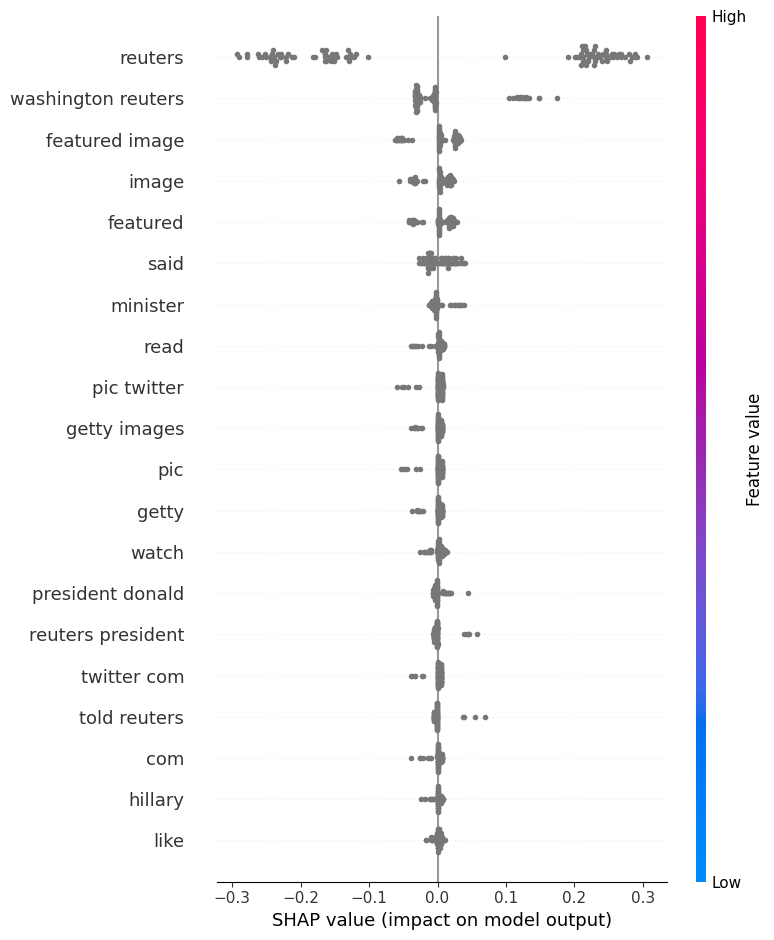

In [53]:
shap.summary_plot(
    shap_values_class1, 
    X_test_selected[:100],
    feature_names=feature_names,
    plot_type="dot",
    max_display=20,
    title="Random Forest Feature Importance"
)

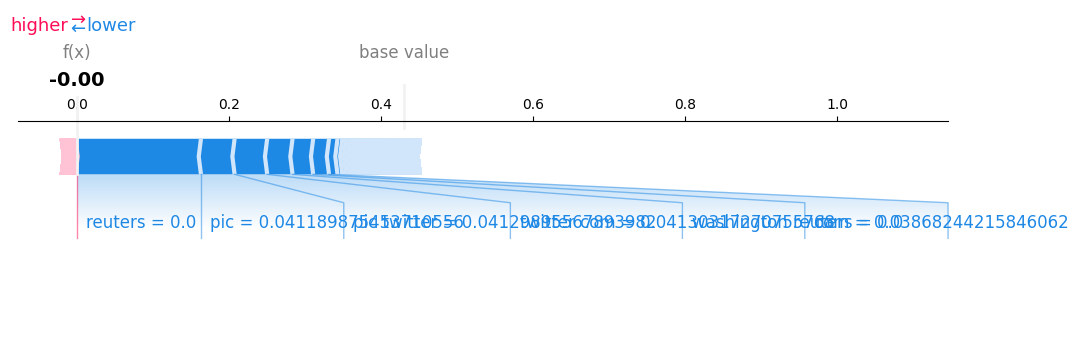

In [ ]:
shap.plots.force(
    base_value=explainer_rf.expected_value[1],
    shap_values=shap_values_class1[0],
    features=X_test_selected_dense[0],
    feature_names=feature_names,
    matplotlib=True,
    figsize=(12, 3)
)


In [55]:
np.savez('rf_shap_metadata.npz',
         expected_value=explainer_rf.expected_value,
         feature_names=feature_names,
         X_test=X_test_selected_dense)

In [56]:
np.savez('rf_shap_data.npz',
    shap_values=shap_values_class1,
    expected_value=explainer_rf.expected_value,
    feature_names=feature_names,
    X_test=X_test_selected_dense
)